In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from keras.models import Sequential
from keras.models import Model
from keras.layers import Dense, Input, LSTM, Dropout

In [5]:
def load_activity_map():
    map = {}
    map[0] = 'transient'
    map[1] = 'lying'
    map[2] = 'sitting'
    map[3] = 'standing'
    map[4] = 'walking'
    map[5] = 'running'
    map[6] = 'cycling'
    map[7] = 'Nordic_walking'
    map[9] = 'watching_TV'
    map[10] = 'computer_work'
    map[11] = 'car driving'
    map[12] = 'ascending_stairs'
    map[13] = 'descending_stairs'
    map[16] = 'vacuum_cleaning'
    map[17] = 'ironing'
    map[18] = 'folding_laundry'
    map[19] = 'house_cleaning'
    map[20] = 'playing_soccer'
    map[24] = 'rope_jumping'
    return map

In [6]:
#названия датчиков 
observables = ['3D_acceleration_16', '3D_acceleration_6', '3D_gyroscope', '3D_magnetometer']

# (температура + 3D оси + 4D ориентация)
sensor = (
    ['temperature'] + 
    [f'{obs}_{axis}' for obs in observables for axis in ['x', 'y', 'z']] + 
    [f'4D_orientation_{axis}' for axis in ['x', 'y', 'z', 'w']]
)

#  финальный список колонок 
columns_names = (
    ['time_stamp', 'activity_id', 'heart_rate'] + 
    [f'{part}_{item}' for part in ['hand', 'chest', 'ankle'] for item in sensor]
)


In [7]:
data_dir = 'PAMAP2_Dataset/Protocol'
os.path.exists(data_dir)

True

In [8]:
#  удаляем 'orientation' и 'time_stamp' 
cols_to_drop = [col for col in columns_names if 'orientation' in col] + ['time_stamp']


In [10]:
df_init = None
df_list = []
for file_name in os.listdir(data_dir):
    # Читаем файл
    df_temp = pd.read_csv(os.path.join(data_dir, file_name), sep=' ', header=None, names=columns_names)
    df_temp.drop(columns=cols_to_drop, inplace=True)
    df_temp = df_temp[df_temp['activity_id'] != 0]
    
    # ВАЖНО: Вытаскиваем только цифры из имени файла (например, 'subject101.dat' -> 101)
    subject_id = int(''.join(filter(str.isdigit, file_name)))
    
    # Добавляем колонку id в этот кусочек данных
    df_temp['id'] = subject_id
    
    print(f'file {file_name} (Subject {subject_id}), {df_temp.shape = }')
    df_list.append(df_temp)

# Склеиваем всё заново
df_init = pd.concat(df_list, ignore_index=True)



file subject101.dat (Subject 101), df_temp.shape = (249957, 42)
file subject102.dat (Subject 102), df_temp.shape = (263349, 42)
file subject103.dat (Subject 103), df_temp.shape = (174338, 42)
file subject104.dat (Subject 104), df_temp.shape = (231421, 42)
file subject105.dat (Subject 105), df_temp.shape = (272442, 42)
file subject106.dat (Subject 106), df_temp.shape = (250096, 42)
file subject107.dat (Subject 107), df_temp.shape = (232776, 42)
file subject108.dat (Subject 108), df_temp.shape = (262102, 42)
file subject109.dat (Subject 109), df_temp.shape = (6391, 42)


In [11]:
def fix_data(data):
    data = data.drop(data[data['activity_id']==0].index)
    data = data.interpolate()
    # fill all the NaN values in a coulmn with the mean values of the column
    for colName in data.columns:
        data[colName] = data[colName].fillna(data[colName].mean())
    activity_mean = data.groupby(['activity_id']).mean().reset_index()
    return data

data = fix_data(df_init)

In [12]:
data.describe()

,activity_id,heart_rate,hand_temperature,hand_3D_acceleration_16_x,hand_3D_acceleration_16_y,hand_3D_acceleration_16_z,hand_3D_acceleration_6_x,hand_3D_acceleration_6_y,hand_3D_acceleration_6_z,hand_3D_gyroscope_x,...,ankle_3D_acceleration_6_x,ankle_3D_acceleration_6_y,ankle_3D_acceleration_6_z,ankle_3D_gyroscope_x,ankle_3D_gyroscope_y,ankle_3D_gyroscope_z,ankle_3D_magnetometer_x,ankle_3D_magnetometer_y,ankle_3D_magnetometer_z,id
count,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,...,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06,1.942872e+06
mean,8.081830e+00,1.074879e+02,3.275126e+01,-4.952973e+00,3.585079e+00,3.602232e+00,-4.886286e+00,3.573597e+00,3.786931e+00,1.480977e-03,...,9.378478e+00,-4.550154e-02,-2.174212e+00,9.960309e-03,-3.652767e-02,6.658552e-03,-3.158971e+01,1.396960e+00,1.725039e+01,1.045664e+02
std,6.174789e+00,2.699215e+01,1.794162e+00,6.239663e+00,6.893705e+00,3.956957e+00,6.245972e+00,6.589666e+00,3.942860e+00,1.332331e+00,...,6.067634e+00,7.190996e+00,3.475429e+00,1.126903e+00,6.383285e-01,2.012898e+00,1.834639e+01,2.168678e+01,1.970652e+01,2.333052e+00
min,1.000000e+00,5.700000e+01,2.487500e+01,-1.453670e+02,-1.043010e+02,-1.014520e+02,-6.121470e+01,-6.184170e+01,-6.193470e+01,-2.813540e+01,...,-6.114200e+01,-6.190640e+01,-6.231480e+01,-2.399500e+01,-1.812690e+01,-1.401960e+01,-1.728650e+02,-1.379080e+02,-1.027160e+02,1.010000e+02
25%,3.000000e+00,8.600000e+01,3.168750e+01,-8.969760e+00,1.058210e+00,1.161470e+00,-8.866490e+00,1.057690e+00,1.363370e+00,-3.784182e-01,...,8.398307e+00,-2.073670e+00,-3.398540e+00,-2.086955e-01,-1.066082e-01,-4.416998e-01,-4.171632e+01,-1.248465e+01,3.794668e+00,1.020000e+02
50%,6.000000e+00,1.040000e+02,3.312500e+01,-5.450280e+00,3.526550e+00,3.431410e+00,-5.378515e+00,3.567850e+00,3.662640e+00,-5.993640e-03,...,9.551120e+00,-2.252230e-01,-1.991685e+00,4.606210e-03,-3.950165e-03,-2.327570e-03,-3.400820e+01,7.769370e-01,1.876755e+01,1.050000e+02
75%,1.300000e+01,1.240000e+02,3.406250e+01,-9.577087e-01,6.453505e+00,6.531523e+00,-9.058870e-01,6.458670e+00,6.775980e+00,3.360765e-01,...,1.028590e+01,1.921310e+00,-5.946650e-01,1.310400e-01,1.162570e-01,9.181807e-02,-1.790600e+01,1.783892e+01,3.121160e+01,1.070000e+02
max,2.400000e+01,2.020000e+02,3.550000e+01,6.285960e+01,1.556990e+02,1.577600e+02,5.282140e+01,6.225980e+01,6.192340e+01,2.641580e+01,...,6.196930e+01,6.204900e+01,6.093570e+01,1.742040e+01,1.358820e+01,1.652880e+01,9.155160e+01,9.424780e+01,1.469000e+02,1.090000e+02


In [13]:
def pd_fast_plot(pd,column_a,column_b,title, figsize=(10,6)):
    plt.rcParams.update({'font.size': 16})
    size = range(len(pd))
    f, ax = plt.subplots(figsize=figsize) 
    plt.bar(size, pd[column_a], color=plt.cm.Paired(size))
    a = ax.set_xticklabels(pd[column_b])
    b = ax.legend(fontsize = 20)
    c = ax.set_xticks(np.arange(len(pd)))
    d = ax.set_title(title)
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6084\1872883728.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a = ax.set_xticklabels(pd[column_b])
C:\Users\Admin\AppData\Local\Temp\ipykernel_6084\1872883728.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  b = ax.legend(fontsize = 20)


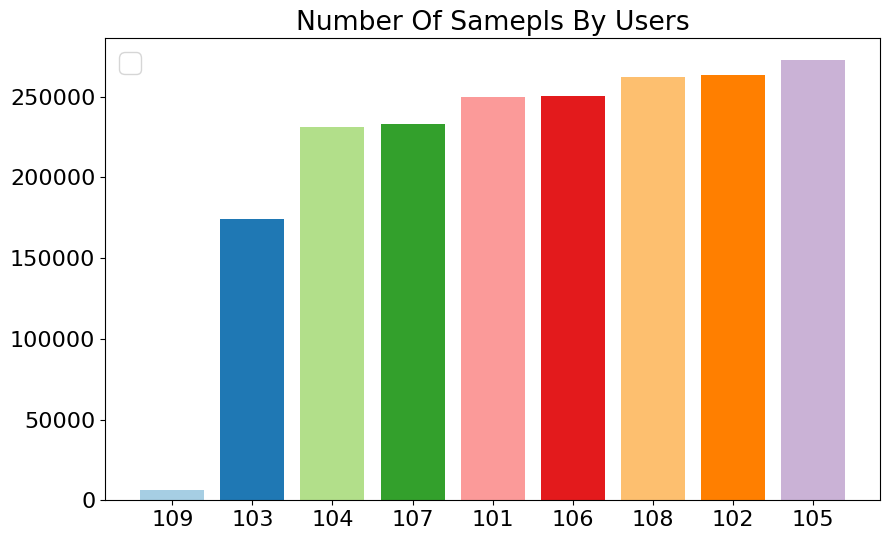

In [14]:
sampels = data.groupby(['id']).count().reset_index()
sampels_to_subject = pd.DataFrame()
sampels_to_subject['id'] = sampels['id']
sampels_to_subject['sampels'] = sampels['activity_id']
sampels_to_subject = sampels_to_subject.sort_values(by=['sampels'])
pd_fast_plot(sampels_to_subject,'sampels','id','Number Of Samepls By Users')

C:\Users\Admin\AppData\Local\Temp\ipykernel_6084\1872883728.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a = ax.set_xticklabels(pd[column_b])
C:\Users\Admin\AppData\Local\Temp\ipykernel_6084\1872883728.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  b = ax.legend(fontsize = 20)


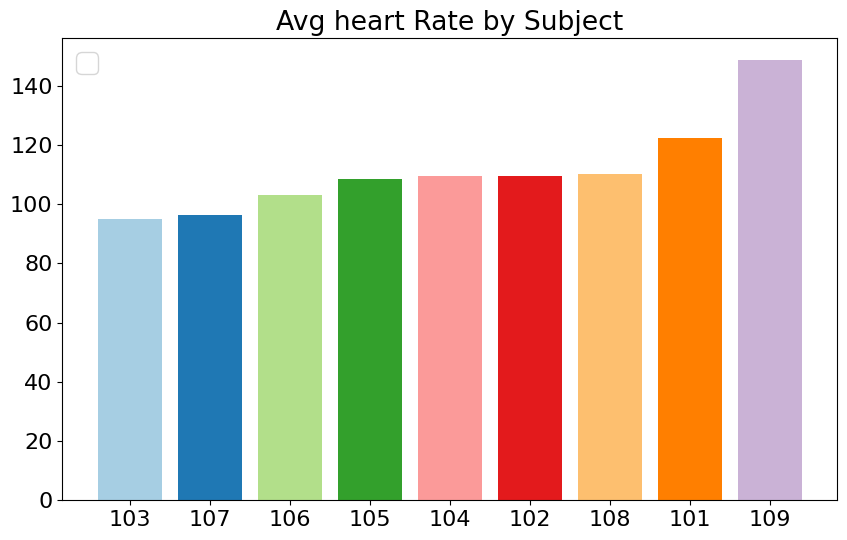

In [15]:
# 1. Сначала создаем result_id, считая средние показатели по каждому пользователю
result_id = data.groupby(['id']).mean().reset_index()

# 2. И только потом собираем данные для графика
sampels_heart_rate = pd.DataFrame()
sampels_heart_rate['id'] = result_id['id']
sampels_heart_rate['heart_rate'] = result_id['heart_rate']
sampels_heart_rate = sampels_heart_rate.sort_values(by=['heart_rate'])

# 3. Строим график
pd_fast_plot(sampels_heart_rate, 'heart_rate', 'id', 'Avg heart Rate by Subject')


[Text(0, 0, '101'),
 Text(1, 0, '102'),
 Text(2, 0, '103'),
 Text(3, 0, '104'),
 Text(4, 0, '105'),
 Text(5, 0, '106'),
 Text(6, 0, '107'),
 Text(7, 0, '108'),
 Text(8, 0, '109')]

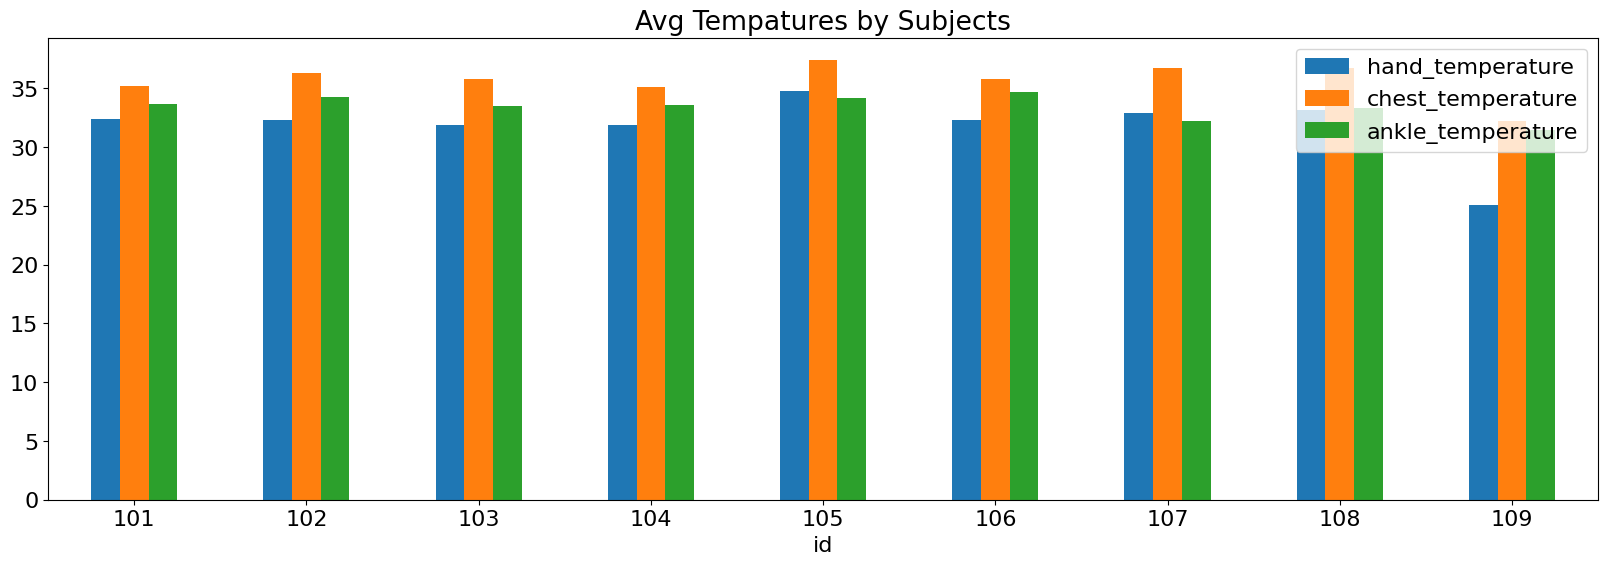

In [16]:
# Выбираем нужные колонки, переименовываем их и сразу строим график
ax = result_id.set_index('id')[['hand_temperature', 'chest_temperature', 'ankle_temperature']].plot(
    kind='bar', 
    figsize=(20, 6), 
    title='Avg Tempatures by Subjects'
)
ax.set_xticklabels(result_id['id'], rotation=0)


[Text(0, 0, 'lying'),
 Text(1, 0, 'sitting'),
 Text(2, 0, 'standing'),
 Text(3, 0, 'walking'),
 Text(4, 0, 'running'),
 Text(5, 0, 'cycling'),
 Text(6, 0, 'Nordic_walking'),
 Text(7, 0, 'ascending_stairs'),
 Text(8, 0, 'descending_stairs'),
 Text(9, 0, 'vacuum_cleaning'),
 Text(10, 0, 'ironing'),
 Text(11, 0, 'rope_jumping')]

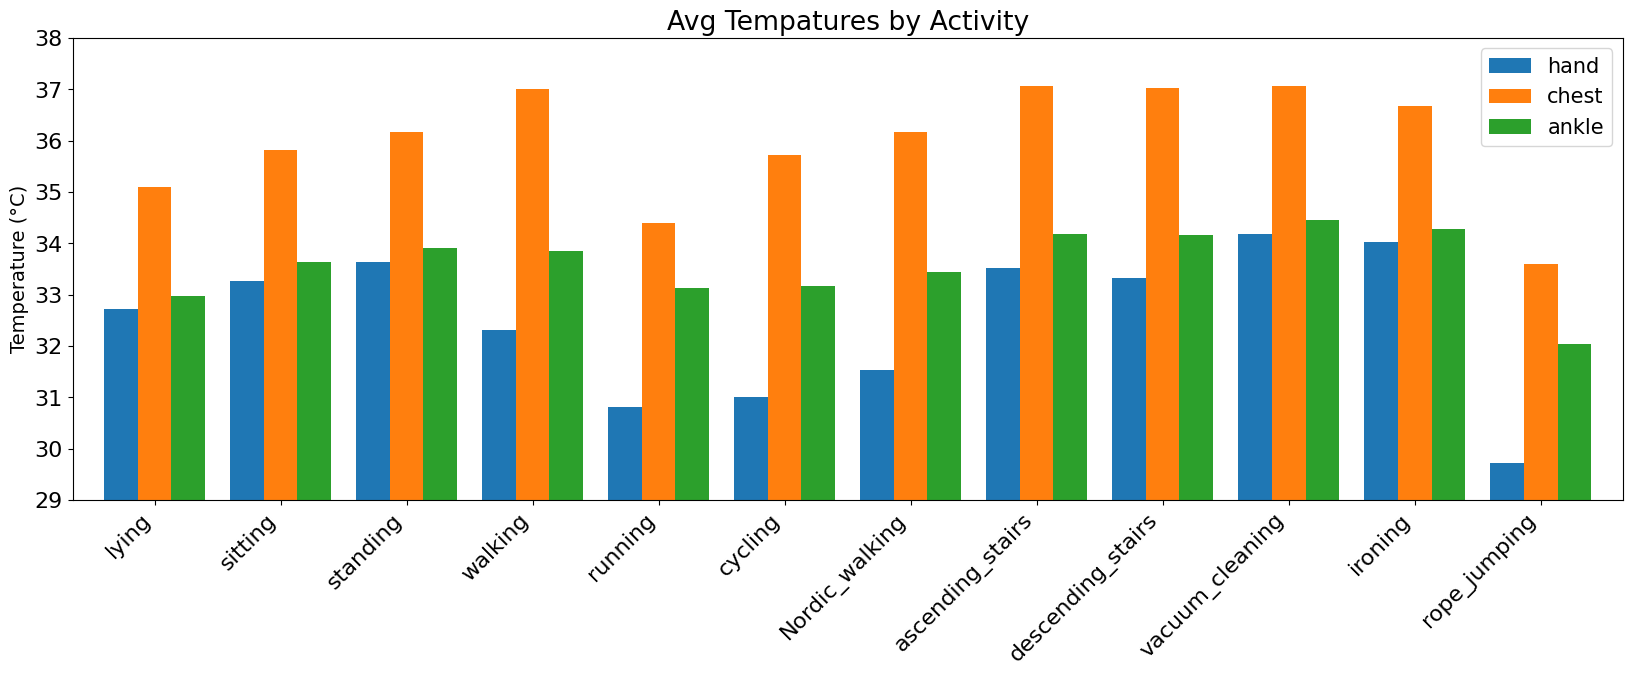

In [17]:
# 1. СНАЧАЛА СОЗДАЕМ result_act (группируем данные по активностям и считаем среднее)
result_act = data.groupby(['activity_id']).mean().reset_index()

# 2. Получаем словарь названий активностей
map_ac = load_activity_map()

# 3. Собираем датафрейм, используя .values для защиты от рассинхронизации индексов
samepls_tempreture = pd.DataFrame()
samepls_tempreture['hand'] = result_act['hand_temperature'].values
samepls_tempreture['chest'] = result_act['chest_temperature'].values
samepls_tempreture['ankle'] = result_act['ankle_temperature'].values

# В качестве индекса устанавливаем текстовые названия активностей из словаря
samepls_tempreture.index = [map_ac[x] for x in result_act['activity_id']]

# 4. Строим столбчатый график (kind='bar')
ax = samepls_tempreture.plot(
    kind='bar', 
    figsize=(20, 6),  # Размер 20х6 обычно аккуратнее, но можно вернуть 40х6, если названий слишком много
    title='Avg Tempatures by Activity',
    width=0.8
)
ax.set_ylim(29, 38)
# 5. Настраиваем подписи (теперь они берутся из индекса автоматически)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.legend(fontsize=15)

# Поворачиваем длинные названия активностей на 45 градусов, чтобы они не налезали друг на друга
ax.set_xticklabels(samepls_tempreture.index, rotation=45, ha='right')


C:\Users\Admin\AppData\Local\Temp\ipykernel_6084\1352762942.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a = ax.set_xticklabels(result_id['id'])


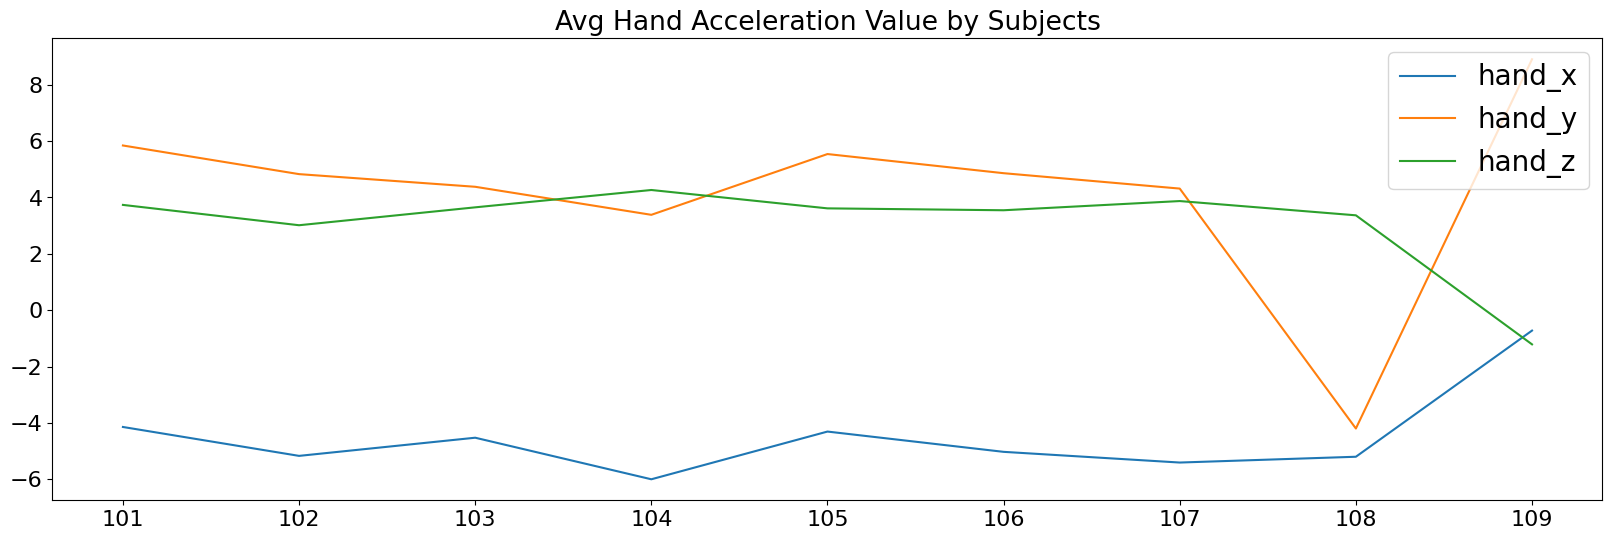

In [18]:
samepls = pd.DataFrame()
samepls['hand_x'] = result_id['hand_3D_acceleration_16_x']
samepls['hand_y'] = result_id['hand_3D_acceleration_16_y']
samepls['hand_z'] = result_id['hand_3D_acceleration_16_z']
ax = samepls.plot(kind='line', figsize=(20,6), title='Avg Hand Acceleration Value by Subjects')
a = ax.set_xticklabels(result_id['id'])
b = ax.legend(fontsize = 20)
c = ax.set_xticks(np.arange(len(samepls)))

In [19]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def split_train_test(data):
    # 1. Выделяем тестовую выборку (субъекты 107 и 108) через pd.concat
    subject107 = data[data['id'] == 107]
    subject108 = data[data['id'] == 108]
    test = pd.concat([subject107, subject108], ignore_index=True)

    # 2. Выделяем тренировочную выборку (все, кроме 107 И 108)
    train = data[(data['id'] != 107) & (data['id'] != 108)]

    # 3. Выделяем целевую переменную y
    y_train = train['activity_id'].values
    y_test = test['activity_id'].values

    # 4. Формируем матрицы признаков X
    # Удаляем 'activity_id' и 'id'. 'time_stamp' НЕ трогаем, так как её уже нет в датасете
    X_train = train.drop(['activity_id', 'id'], axis=1).values
    X_test = test.drop(['activity_id', 'id'], axis=1).values
    
    # 5. Правильное масштабирование без утечки данных
    min_max_scaler = MinMaxScaler()
    
    # Обучаем скалер ТОЛЬКО на тренировочной выборке
    X_train = min_max_scaler.fit_transform(X_train) 
    # Тестовую выборку ТОЛЬКО трансформируем
    X_test = min_max_scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

# Запуск функции
X_train, X_test, y_train, y_test = split_train_test(data)
print('Train shape X :', X_train.shape, ' y ', y_train.shape)
print('Test shape X :', X_test.shape, ' y ', y_test.shape)


Train shape X : (1447994, 40)  y  (1447994,)
Test shape X : (494878, 40)  y  (494878,)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. ОБУЧЕНИЕ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
# ==========================================
print("--- Обучение Логистической регрессии ---")

# max_iter увеличена, так как данных много и модели нужно сойтись к минимуму
log_reg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, y_train)

# Предсказание и оценка
y_pred_lr = log_reg.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Точность Логистической регрессии (Accuracy): {lr_acc:.4f}\n")


# ==========================================
# 2. ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА (RANDOM FOREST)
# ==========================================
print("--- Обучение Случайного леса ---")

# n_estimators=100 (количество деревьев), n_jobs=-1 задействует все ядра процессора
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

# Предсказание и оценка
y_pred_rf = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Точность Случайного леса (Accuracy): {rf_acc:.4f}\n")


# ==========================================
# 3. ПОДРОБНЫЙ ОТЧЕТ ДЛЯ СЛУЧАЙНОГО ЛЕСА
# ==========================================
# Выведем детальные метрики (Precision, Recall, F1-score) для каждого класса активности
print("--- Подробный отчет по классам (Случайный лес) ---")
# Получаем текстовые названия активностей для отчета
map_ac = load_activity_map()
target_names = [map_ac[cls] for cls in sorted(list(set(y_test)))]

print(classification_report(y_test, y_pred_rf, target_names=target_names))


--- Обучение Логистической регрессии ---
Точность Логистической регрессии (Accuracy): 0.5273

--- Обучение Случайного леса ---
Точность Случайного леса (Accuracy): 0.6344

--- Подробный отчет по классам (Случайный лес) ---
                   precision    recall  f1-score   support

            lying       0.98      0.99      0.98     49776
          sitting       0.50      0.93      0.65     35205
         standing       0.84      0.29      0.43     50911
          walking       0.76      0.68      0.72     65253
          running       0.38      0.92      0.54     20224
          cycling       0.75      0.87      0.81     48155
   Nordic_walking       0.90      0.37      0.52     57613
 ascending_stairs       0.52      0.59      0.55     29329
descending_stairs       0.39      0.66      0.49     21273
  vacuum_cleaning       0.41      0.65      0.50     45844
          ironing       0.92      0.48      0.63     62489
     rope_jumping       0.90      0.02      0.04      8806

        

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Переводим метки классов в диапазон от 0 до N-1 (требование XGBoost)
# Наш класс 24 станет, например, классом 12
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("--- Обучение XGBoost на GPU ---")

# n_estimators=100 (количество деревьев)
# device='cuda' переносит все вычисления на GPU
model_xgb = XGBClassifier(
    n_estimators=100, 
    device='cuda', 
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train, y_train_encoded)

# Предсказание
y_pred_xgb = model_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test_encoded, y_pred_xgb)

print(f"Точность XGBoost на GPU (Accuracy): {xgb_acc:.4f}")


--- Обучение XGBoost на GPU ---


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [19:07:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Точность XGBoost на GPU (Accuracy): 0.5245
